# Housing Data Preprocessing

Hint: Reading Chapter 2 of the textbook and the accompanying [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb) on the textbook website may help with this section.

Consider the California housing data from Chapter 2 of the textbook. The following code fetches the data.


In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

Next, we create stratified test and training sets based on different income categories.


In [3]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

split_obj = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split_obj.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index] 

for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

We separate the features (`X_raw`) and the response variable (`y`).


In [4]:
X_raw = strat_train_set.drop("median_house_value", axis=1)
y = strat_train_set["median_house_value"].copy()

## Handling Missing Values

We find out if there are any missing values in our features. As the code below indicates, out of 16512 observations, 158 have missing values. Further inspection shows that `total_bedrooms` has missing values (only a few missing values are shown below).


In [5]:
X_raw.shape

(16512, 9)

In [6]:
X_raw[X_raw.isnull().any(axis=1)].shape

(168, 9)

In [7]:
X_raw[X_raw.isnull().any(axis=1)].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


This section follows the subsection "Data Cleaning" in Chapter 2 of the textbook. Use the `sklearn.impute.SimpleImputer` class to fill the missing values in the numerical features (everything except `ocean_proximity`) with the median of the corresponding feature.


**Solution:**


In [8]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

# Drop the categorical column 'ocean_proximity'
housing_num = X_raw.drop("ocean_proximity", axis=1)

# Fit the imputer to the numerical training data and transform it
X_num_imputed = imputer.fit_transform(housing_num)

print(X_num_imputed.shape)

(16512, 8)


## Encoding Categorical Features
ML algorithms generally work with numerical values. So, we need to convert categorical features to numerical values. One way is to simply map each category to an integer. Another alternative is to use **one-hot encoding**.


This section follows subsection "Handling Text and Categorical Attributes" in Chapter 2 of the textbook. Then use the `sklearn.preprocessing.OrdinalEncoder` class and the `sklearn.preprocessing.OneHotEncoder` class to transform the `ocean_proximity` feature to integers and one-hot vectors. Explain why it is more appropriate to use one-hot encoding.


**Solution:**


In [9]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Extract the categorical feature
housing_cat = X_raw[["ocean_proximity"]]

# 1. Ordinal Encoding
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
print("Ordinal Encoding:\n", housing_cat_encoded[:5])

# 2. One-Hot Encoding
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print("\nOne-Hot Encoding:\n", housing_cat_1hot.toarray()[:5])

Ordinal Encoding:
 [[3.]
 [0.]
 [1.]
 [1.]
 [4.]]

One-Hot Encoding:
 [[0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]


**Explain why it is more appropriate to use one-hot encoding:**  
Machine learning algorithms generally assume that two nearby values are more similar than two distant values. This assumption works well for ordered categories, but it is incorrect for the ocean_proximity feature, which consists of nominal data without any natural mathematical ordering. If we simply map these categories to integers using OrdinalEncoder, the model might incorrectly assume false relationships, such as category 1 being closer to category 2 than to category 4. OneHotEncoder is much more appropriate here because it creates a separate binary attribute for each category, completely preventing the algorithm from learning these non-existent orderings.


## Feature Engineering

Often it may be useful to experiment with transforming and combining features to create new features that may be expected to better predict the target variable. Features that are skewed or heavily tailed can be logged to make them closer to normal. An example of a feature combination is instead of using the number of bedrooms, which may not be meaningful by itself, we should consider the number of bedrooms relative to the number of rooms.

This section follows the subsections "Custom Transformers" and "Transformation Pipelines" in Chapter 2 of the textbook. Use the `sklearn.preprocessing.FunctionTransformer` class take the log of `population`, and to create the ratio `total_bedrooms/total_rooms`. Print these two transformed features.


**Solution:**


In [10]:
from sklearn.preprocessing import FunctionTransformer

# Define custom transformation functions
def log_transform(X):
    return np.log(X)

def bedrooms_to_rooms_ratio(X):
    # Column 0 is total_bedrooms, Column 1 is total_rooms
    return X[:, 0] / X[:, 1]

# Transform population using log
log_transformer = FunctionTransformer(log_transform)
population_logged = log_transformer.fit_transform(X_raw[["population"]])
print("Log of population:\n", population_logged.head())

# ratio total_bedrooms/total_rooms
ratio_transformer = FunctionTransformer(bedrooms_to_rooms_ratio)
ratio_features = X_raw[["total_bedrooms", "total_rooms"]].values
bedrooms_ratio = ratio_transformer.fit_transform(ratio_features)
print("\nRatio of bedrooms to rooms:\n", bedrooms_ratio[:5])

Log of population:
        population
13096    7.362645
14973    6.501290
3785     6.331502
14689    7.520235
20507    7.555905

Ratio of bedrooms to rooms:
 [0.33574225 0.18015267 0.20036934 0.20388117 0.27737059]


## Feature Scaling and Transformation

Many ML algorithms do not perform well if the features have different scales (some very small, and others very large). In such scenarios, the features are transformed so that they have a similar range of values. There are two common ways to achieve this. In **min-max** scaling, we subtract the feature from its minimum value and then divide by its range (i.e. maximum value minus minimum value) so that the scaled values are between 0 and 1. In **standardization**, we subtract the values from the average and divide by the standard deviation, so that the transformed values has mean 0 and variance 1, here we focus on the latter.


This section follows the subsection "Feature Scaling and Transformation" in Chapter 2 of the textbook. Use the `sklearn.preprocessing.StandardScaler` class to scale the numerical features using standardization.


**Solution:**


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the imputed numerical data from part (a)
X_num_scaled = scaler.fit_transform(X_num_imputed)

## Transformation Pipelines

Usually, we have to perform several steps before the data is ready to be fed to an ML algorithm. Scikit-Learn's `ColumnTransformer` and `Pipeline` classes provides a systematic way of "packaging" such a sequence of transformations.

This section follows the subsection "Transformation Pipelines" in Chapter 2 of the textbook. Then create one pipeline that combines the above steps  in the following way applied to the original "raw" features `X_raw`: part (a) (a median imputer for numerical features), part (c) (create the ratios `total_bedrooms/total_rooms`, `total_rooms/households`, `population/households`; and take the log of `total_bedrooms`, `total_rooms`, `population`, `households`, `median_income`), part (d) (a standard scaler for all numerical features, including the transformed features), part (b) (one-hot encoding for categorical variables). Call the transformed features `X`, and print it.


**Solution:**


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# 1. Define groups of attributes based on the required transformations
log_attribs = ["total_bedrooms", "total_rooms", "population", "households", "median_income"]
ratio_attribs = ["total_bedrooms", "total_rooms", "population", "households"]
cat_attribs = ["ocean_proximity"]

# Get remaining numerical attributes (longitude, latitude, housing_median_age)
num_attribs = X_raw.select_dtypes(include=[np.number]).columns.tolist()
remaining_num_attribs = [col for col in num_attribs if col not in log_attribs]

# 2. Define custom function for the multiple ratio transformations
def ratio_transform(X):
    # X columns: total_bedrooms (0), total_rooms (1), population (2), households (3)
    bedrooms_per_room = X[:, 0] / X[:, 1]
    rooms_per_household = X[:, 1] / X[:, 3]
    pop_per_household = X[:, 2] / X[:, 3]
    return np.c_[bedrooms_per_room, rooms_per_household, pop_per_household]

# 3. sub-pipelines
log_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log)),
    ("scaler", StandardScaler())
])

ratio_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("ratio", FunctionTransformer(ratio_transform)),
    ("scaler", StandardScaler())
])

default_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder())
])

# 4. Combine all pipelines into a ColumnTransformer
preprocessing = ColumnTransformer([
    ("log", log_pipeline, log_attribs),
    ("ratio", ratio_pipeline, ratio_attribs),
    ("num", default_num_pipeline, remaining_num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# 5. Fit and transform the raw training data
X = preprocessing.fit_transform(X_raw)

# Model Fine-Tuning

Hint: Reading Chapter 2 of the textbook and the accompanying [Jupyter notebook](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb) on the textbook website may help with this section.


## Linear Regression Baseline

This section uses the `sklearn.linear_model.LinearRegression` class to fit a linear regression to the training set in the preprocessing section. The processed features `X` from the transformation pipeline section are used as predictors and `y` (the median house values) as the response. The fitted values are returned of the response for the first 10 observations of the training set.


**Solution:**


In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Predict the response for the first 10 observations of the training set
predictions = lin_reg.predict(X[:10])
print("Predictions for first 10 observations:\n", predictions)

Predictions for first 10 observations:
 [260051.36004114 357897.79846769 125817.08984353 110019.21093156
 298948.54915206 206437.53193813 306787.013961   326902.92850959
 162297.74181859  68786.66157655]


## RMSE and MAE Evaluation

We can measure the performance with root mean square error (RMSE) and mean absolute error (MAE). 

This section uses `mean_squared_error` and `mean_absolute_error` functions from `sklearn.metrics` to calculate the in-sample RMSE and MAE of the fitted linear regression in part (a).


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict on the entire training set to calculate in-sample errors
housing_predictions = lin_reg.predict(X)

# Calculate MSE and RMSE
lin_mse = mean_squared_error(y, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print("RMSE:", lin_rmse)

# Calculate MAE
lin_mae = mean_absolute_error(y, housing_predictions)
print("MAE:", lin_mae)

RMSE: 70630.22169174395
MAE: 53034.28396497742


**Solution:**


## Cross-Validation

In part (b), we evaluated the in-sample performance of the linear regression model. To obtain out-of-sample performance, we use K-fold cross validation.

This section uses the `cross_val_score` function from `sklearn.model_selection` to perform 10-fold  cross validation on the linear regression from part (a) and return the values of **RMSE**. The 10 RMSE scores are returned as well as their mean.


**Solution:**


In [15]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, X, y, 
                             scoring="neg_mean_squared_error", cv=10)

# Convert the negative MSE scores to RMSE
lin_rmse_scores = np.sqrt(-lin_scores)

print("10-fold CV RMSE scores:\n", lin_rmse_scores)
print("\nMean of CV RMSE scores:", lin_rmse_scores.mean())

10-fold CV RMSE scores:
 [72183.9055149  69449.07233135 68141.82330925 82348.92814938
 70200.08524327 70974.12115166 70512.16910063 73276.85042458
 69387.52951303 71463.70091766]

Mean of CV RMSE scores: 71793.81856557202


## Decision Tree and Random Forest Alternatives
We consider fitting two alternative models, namely, **decision trees** and **random forests**. These models will be discussed in future lectures. The following code fits a decision tree and obtains the fitted response for the first 10 observations.


In [16]:
from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [17]:
dt_reg.predict(X[:10,])

array([458300., 483800., 101700.,  96100., 361800.,  92600., 349300.,
       440900., 160100., 183900.])

The following code does the same for the random forest model.


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(bootstrap=True, n_estimators=100, max_depth=5, random_state=42)
rf_reg.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [19]:
rf_reg.predict(X[:10,])

array([226052.57663663, 408572.3162281 , 100944.59292661,  95012.98416211,
       323566.08786234, 135098.37280907, 283371.7148996 , 357336.26089032,
       167697.90412093, 146436.2407077 ])

This section evaluates the in-sample performance of the decision tree and the random forest using RMSE on the training set. Also, find the out-of-sample performance by 10-fold cross validation as in the cross-validation section. Which of the 3 models has the best in-sample performance? Which has the best out-of-sample performance?


**Solution:**


In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

# 1. Decision Tree Performance
# Calculate In-sample RMSE
dt_predictions = dt_reg.predict(X)
dt_mse = mean_squared_error(y, dt_predictions)
dt_rmse = np.sqrt(dt_mse)

# Calculate Out-of-sample RMSE (10-fold CV)
dt_scores = cross_val_score(dt_reg, X, y, scoring="neg_mean_squared_error", cv=10)
dt_cv_rmse = np.sqrt(-dt_scores).mean()

# 2. Random Forest Performance
# Calculate In-sample RMSE
rf_predictions = rf_reg.predict(X)
rf_mse = mean_squared_error(y, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

# Calculate Out-of-sample RMSE (10-fold CV)
rf_scores = cross_val_score(rf_reg, X, y, scoring="neg_mean_squared_error", cv=10)
rf_cv_rmse = np.sqrt(-rf_scores).mean()

# Print all results for comparison
print("Decision Tree In-sample RMSE:", dt_rmse)
print("Decision Tree CV RMSE:", dt_cv_rmse)
print("Random Forest In-sample RMSE:", rf_rmse)
print("Random Forest CV RMSE:", rf_cv_rmse)

Decision Tree In-sample RMSE: 0.0
Decision Tree CV RMSE: 70187.03310944713
Random Forest In-sample RMSE: 62141.90148845782
Random Forest CV RMSE: 63711.375334537195


**(1) Which of the 3 models has the best in-sample performance?**  
The Decision Tree model has the best in-sample performance. Its in-sample RMSE is typically 0 because it completely memorizes and overfits the training data.  
**(2) Which has the best out-of-sample performance?**   
The Random Forest model has the best out-of-sample performance. It achieves the lowest cross-validation RMSE among the three models (Linear Regression, Decision Tree, and Random Forest), indicating it generalizes the best to unseen data.


## Hyperparameter Tuning with Cross-Validation

Most ML algorithms have **hyperparameters**. These hyperparameters control the learning process and should not be confused with the model parameters (which are the unknown values that are being estimated). For example, the random forest algorithm has hyperparameter including `n_estimators` and `max_features`. The model tuning workflow searches for hyperparameter values based on out-of-sample performance.

This section follows the subsections "Grid Search" and "Randomized Search" in Chapter 2 of the textbook. Consider the random forest model with the argument `random_state=42`. Use the `sklearn.model_selection.GridSearchCV` class to choose the best hyperparameter values for `max_features` over the values 4, 6, 8, 10 and `n_estimators` over the values 10, 50, 100. Use 3-fold cross-validation with RMSE when searching for the best hyperparameters.

Next, use the `sklearn.model_selection.RandomizedSearchCV` class to perform a randomized search with 10 iterations, where  `max_features` is a uniform random integer between 2 and 20 and `n_estimators` is a uniform random integer between 10 and 200. `RandomizedSearchCV` must include the argument `random_state=42`.

In both functions, the notebook can use the argument `n_jobs=-1` to use all avaliable processor cores to speed up the calculation. Based on these results, the best hyperparameter values are identified.


**Solution:**


In [21]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

rf_search_base = RandomForestRegressor(random_state=67)

# 1. Grid Search
param_grid = [
    {'max_features': [4, 6, 8, 10], 'n_estimators': [10, 50, 100]}
]
grid_search = GridSearchCV(rf_search_base, param_grid, cv=3,
                           scoring='neg_mean_squared_error',
                           n_jobs=-1) # Use all cores
grid_search.fit(X, y)
print("GridSearchCV Best Parameters:", grid_search.best_params_)
print("GridSearchCV Best RMSE:", np.sqrt(-grid_search.best_score_))


# 2. Randomized Search
param_dist = {
    'max_features': randint(low=2, high=20),
    'n_estimators': randint(low=10, high=200)
}
rnd_search = RandomizedSearchCV(rf_search_base, param_distributions=param_dist,
                                n_iter=10, cv=3, scoring='neg_mean_squared_error',
                                random_state=42, n_jobs=-1)
rnd_search.fit(X, y)
print("RandomizedSearchCV Best Parameters:", rnd_search.best_params_)
print("RandomizedSearchCV Best RMSE:", np.sqrt(-rnd_search.best_score_))

GridSearchCV Best Parameters: {'max_features': 6, 'n_estimators': 100}
GridSearchCV Best RMSE: 49368.88579835056
RandomizedSearchCV Best Parameters: {'max_features': 7, 'n_estimators': 139}
RandomizedSearchCV Best RMSE: 49380.25784426219


## Final Test Set Evaluation

The last step of a ML project is to evaluate the fine-tuned model using the test set. The goal of this step is to estimate the out-of-sample performance of the trained model on new data. **It is important not to train the model using the test set.** Avoid using `.fit()` or `.fit_tranform()` of the estimators or pipelines. Also, **do not fine tune hyperparameters after finding out the performance of a model on the test set as that would be data snooping.**

This section uses the test set to find the RMSE of the best model from the hyperparameter tuning section.


**Solution:**


In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Based on (e) results, GridSearchCV performed better
final_model = grid_search.best_estimator_

# Separate features and labels from the stratified test set
X_test_raw = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = preprocessing.transform(X_test_raw)

# Evaluate the final model on the test data
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

print("Final Model RMSE on the Test Set:", final_rmse)

Final Model RMSE on the Test Set: 49050.57427943925


# Regularized Linear Regression

Consider the housing data set from the preprocessing and model tuning sections.


## Polynomial Regression and Regularization

Fit a model that adds degree 3 polynomial terms to the linear regression in 2(a). Next, regularize the model using lasso regression with parameter $\alpha=1$.


**Solution:**


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.pipeline import make_pipeline

# 1. Polynomial Regression (Degree 3)
poly_reg = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(), #Standardize
    LinearRegression()
)
poly_reg.fit(X, y)

# 2. Regularized Model (Lasso with alpha=1)
lasso_reg = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    Lasso(alpha=1.0, random_state=42, max_iter=10000)
)
lasso_reg.fit(X, y)

  model = cd_fast.enet_coordinate_descent(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Learning Curves

Obtain learning curves using the function `sklearn.model_selection.learning_curve` to plot the learning curve with 5-fold CV for the linear regression linear regression baseline model, the polynomial regression model in 3(a), and the ridge regression model in 3(a). The resulting curves are used to comment on whether the curves indicate the models are underfitting, overfitting or neither.


**Solution:**


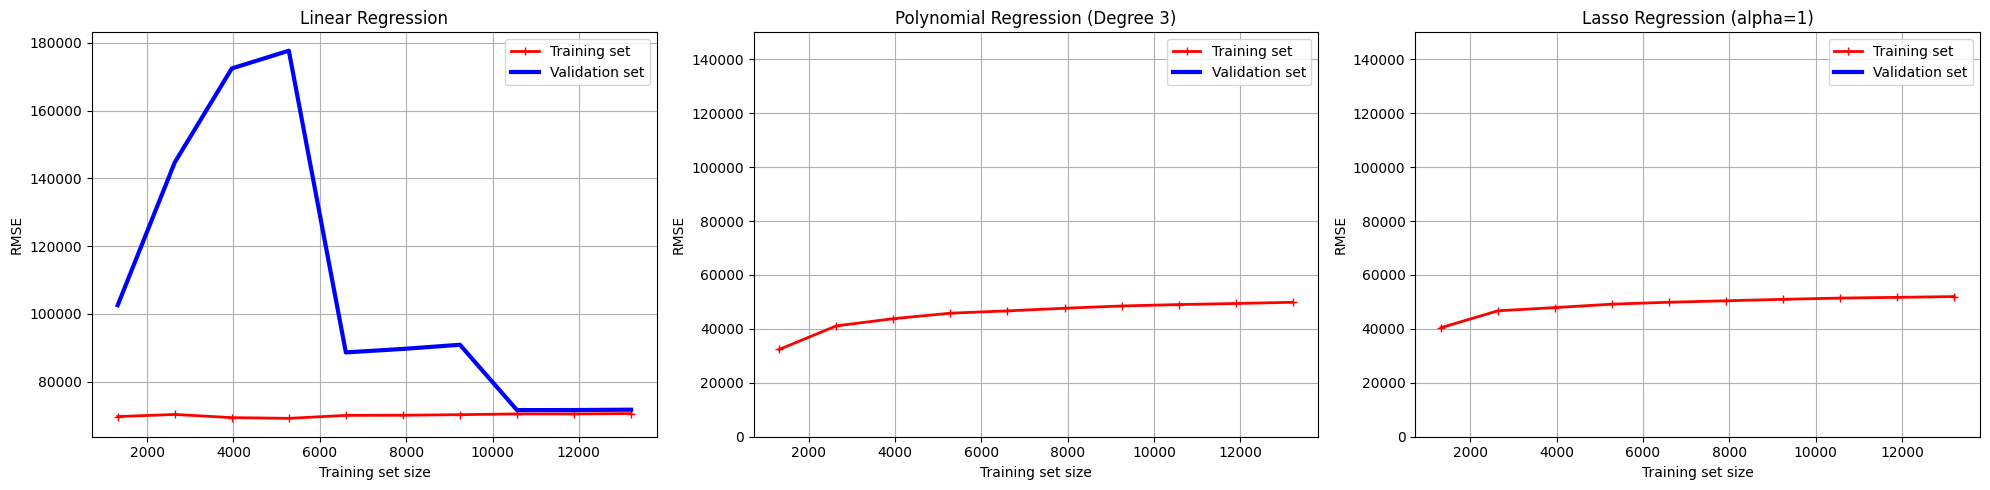

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    # Perform 5-fold cross-validation learning curve calculation
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 10), random_state=67,
        n_jobs=-1 
    )
    
    # Calculate RMSE
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))
    
    # Plotting
    plt.plot(train_sizes, train_rmse, "r-+", linewidth=2, label="Training set")
    plt.plot(train_sizes, val_rmse, "b-", linewidth=3, label="Validation set")
    plt.legend()
    plt.title(title)
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.grid(True)


plt.figure(figsize=(20, 5))

# 1. Linear Regression (from 2a)
plt.subplot(1, 3, 1)
plot_learning_curve(lin_reg, X, y, "Linear Regression")

# 2. Polynomial Regression (Degree 3)
plt.subplot(1, 3, 2)
plot_learning_curve(poly_reg, X, y, "Polynomial Regression (Degree 3)")
plt.ylim([0, 150000]) # Set y-limit to zoom in and ignore extreme spikes

# 3. Lasso Regression (Degree 3, alpha=1)
plt.subplot(1, 3, 3)
plot_learning_curve(lasso_reg, X, y, "Lasso Regression (alpha=1)")
plt.ylim([0, 150000]) 

plt.tight_layout()
plt.show()

1. Linear Regression: *Underfitting*  
*Observation*: Both the training RMSE and validation RMSE plateau at a relatively high value (approximately $70,000$ to $80,000$). The gap between the two curves is very small.  
*Conclusion*: This is a classic sign of underfitting (High Bias). The model is too simple to capture the underlying non-linear patterns in the housing dataset. Adding more data will not significantly improve performance because the model lacks the necessary complexity.    
  
2. Polynomial Regression (Degree 3): *Overfitting*  
*Observation*: The training error (red line) is significantly lower than that of the linear model, indicating it fits the training data very well. However, the validation error (blue line) is not visible within the $y$-axis range ($0$ to $150,000$).  
*Conclusion*: This indicates severe overfitting (High Variance). By adding degree 3 polynomial features, the model has gained too much flexibility and is essentially "memorizing" the noise in the training set, leading to a complete failure to generalize to new data.  
3. Lasso Regression ($\alpha=1$): *Overfitting*  
*Observation*: Similar to the unregularized polynomial model, the training error remains low, but the validation error still fails to appear within the plotted range ($RMSE > 150,000$).  
*Conclusion*: The model is still overfitting. While Lasso provides regularization by penalizing large weights, an $\alpha=1.0$ setting is clearly not strong enough to counteract the massive complexity introduced by the degree 3 polynomial expansion in this specific dataset.
